# Building a Review-Based Book Recommender

Need to upload data/10000_reviews.csv and data/book_titles.csv to run

In this notebook we will:

1. **Load & join** user reviews with book metadata  
2. **Clean** free-text fields (reviews, descriptions)  
3. **Explore** data quality and distribution  
4. **Classify** books as *fiction* vs *non-fiction* using TF-IDF + Logistic Regression  
5. **Generate embeddings** from book descriptions using a Sentence Transformer  
6. **Build a vector search engine** to find books similar to a user’s query based on semantic meaning  
7. **Safely apply sentiment analysis** (using a pre-trained LLM) to label each book’s tone as *positive*, *negative*, or *neutral*  
8. **Filter recommendations** by genre and tone preferences  
9. **Deploy an interactive Gradio dashboard** where users can enter a plot idea, choose filters, and get recommended books  

In [1]:
import pandas as pd
import re
import ast
from sentence_transformers import SentenceTransformer
import joblib

/Users/mollystark/Desktop/michigan/capstone/SIADS-Capstone/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load the Datasets (Colab)

In [2]:
# from google.colab import files
# import io

# # Upload files
# uploaded = files.upload()  # User selects two CSVs

# # Convert uploaded files into DataFrames
# dfs = []
# for fname in uploaded:
#     df = pd.read_csv(io.BytesIO(uploaded[fname]))
#     dfs.append((fname, df))

# # Identify which file is which based on expected columns
# reviews_df = None
# book_names_df = None

# for fname, df in dfs:
#     cols = set(df.columns)
#     if {'review_text', 'rating', 'user_id', 'book_id'}.issubset(cols):
#         reviews_raw_df = df
#         print(f"Detected reviews file: {fname}")
#     elif {'title', 'description', 'book_id'}.issubset(cols):
#         book_names_df = df
#         print(f"Detected book titles file: {fname}")
#     else:
#         print(f"Could not identify file: {fname}")

# # Check and display results
# if reviews_raw_df is not None:
#     print("\nPreview: reviews_raw_df")
#     display(reviews_raw_df.head())
# else:
#     print("Could not find reviews_raw_df.")

# if book_names_df is not None:
#     print("\nPreview: book_names_df")
#     display(book_names_df.head())
# else:
#     print("Could not find book_names_df.")


### Load the Datasets (VSCode)

In [3]:
reviews_raw_df = pd.read_csv('data/10000_reviews.csv')
book_names_df = pd.read_csv('data/book_titles.csv')

In [4]:
# Users reviews information
reviews_raw_df.describe()

,Unnamed: 0,book_id,rating,n_votes,n_comments
count,1.000000e+04,1.000000e+04,10000.000000,10000.000000,10000.000000
mean,6.910120e+05,1.337530e+07,3.695800,3.050500,0.939200
std,3.985966e+05,9.243475e+06,1.232321,12.915968,5.122336
min,1.400000e+01,1.000000e+00,0.000000,0.000000,0.000000
25%,3.525825e+05,6.357565e+06,3.000000,0.000000,0.000000
50%,6.938655e+05,1.333094e+07,4.000000,0.000000,0.000000
75%,1.036109e+06,2.035973e+07,5.000000,2.000000,0.000000
max,1.377876e+06,3.625277e+07,5.000000,444.000000,287.000000


In [5]:
# Book titles information


book_names_df.describe()

,Unnamed: 0,text_reviews_count,average_rating,num_pages,publication_day,publication_month,publication_year,book_id,ratings_count,work_id
count,6301.000000,6301.000000,6301.000000,5968.000000,5362.000000,5505.000000,5622.000000,6.301000e+03,6.301000e+03,6.301000e+03
mean,3150.000000,2652.332804,3.972349,346.728887,14.029280,6.303724,2011.162220,1.393600e+07,5.144573e+04,2.112064e+07
std,1819.086355,6319.195025,0.274742,144.932054,9.772724,3.274454,5.550981,9.537153e+06,1.955803e+05,1.618190e+07
min,0.000000,20.000000,2.460000,1.000000,1.000000,1.000000,1950.000000,1.000000e+00,4.200000e+01,1.140000e+02
25%,1575.000000,332.000000,3.810000,274.000000,5.000000,4.000000,2010.000000,6.492981e+06,2.561000e+03,6.405906e+06
50%,3150.000000,825.000000,3.990000,336.000000,13.000000,6.000000,2013.000000,1.361296e+07,8.227000e+03,1.884156e+07
75%,4725.000000,2268.000000,4.160000,401.000000,23.000000,9.000000,2014.000000,2.141385e+07,2.861300e+04,3.117587e+07
max,6300.000000,142645.000000,4.770000,1859.000000,31.000000,12.000000,2018.000000,3.625277e+07,4.899965e+06,5.799794e+07


In [6]:
# Make a copy BEFORE any cleaning
reviews_df = reviews_raw_df.copy()

In [7]:
# Merge the two dataset

merged_df = reviews_df.merge(book_names_df, on='book_id', how='left')


In [8]:
merged_df.keys()

Index(['Unnamed: 0_x', 'user_id', 'book_id', 'review_id', 'rating',
       'review_text', 'date_added', 'date_updated', 'read_at', 'started_at',
       'n_votes', 'n_comments', 'Unnamed: 0_y', 'isbn', 'text_reviews_count',
       'series', 'country_code', 'language_code', 'popular_shelves', 'asin',
       'is_ebook', 'average_rating', 'kindle_asin', 'similar_books',
       'description', 'format', 'link', 'authors', 'publisher', 'num_pages',
       'publication_day', 'isbn13', 'publication_month', 'edition_information',
       'publication_year', 'url', 'image_url', 'ratings_count', 'work_id',
       'title', 'title_without_series'],
      dtype='object')

In [9]:
# Check missing values
merged_df.isnull().sum()

Unnamed: 0_x               0
user_id                    0
book_id                    0
review_id                  0
rating                     0
review_text                0
date_added                 0
date_updated               0
read_at                  953
started_at              2920
n_votes                    0
n_comments                 0
Unnamed: 0_y               0
isbn                    1890
text_reviews_count         0
series                     0
country_code               0
language_code            507
popular_shelves            0
asin                    8862
is_ebook                   0
average_rating             0
kindle_asin             1051
similar_books              0
description               61
format                  1271
link                       0
authors                    0
publisher               1383
num_pages                394
publication_day         1372
isbn13                  1641
publication_month       1168
edition_information     8701
publication_ye

## Cleaning User Reviews


In [10]:
# Aggregate reviews for each user
# With rating of 4 and 5 stars

df_high_rated = merged_df[merged_df['rating'] >= 4]

reviews_grouped = (
    df_high_rated
    .groupby('user_id', as_index=False)
    .agg({
        'review_text': lambda x: " ".join(x),
        'book_id': list,
        'rating': list,
        'similar_books': list,
        'authors': list,
        'image_url': list,   # Keeping the thumbnails for displaying book covers
        'title': list

    })
)


reviews_grouped.head()

,user_id,review_text,book_id,rating,similar_books,authors,image_url,title
0,0016a8010771c0c00c97f27dfc5cdd22,One stormy evening Judith McNaught stood at a ...,[129619],[5],"[['107770', '656836', '133499', '330721', '784...","[[{'author_id': '9885', 'role': ''}]]",[https://s.gr-assets.com/assets/nophoto/book/1...,"[A Kingdom of Dreams (Westmoreland, #1)]"
1,00214d8b0a020837cccf5f41eb563037,Even though I gave the book a pretty high rati...,[6582637],[4],"[['6753250', '10557809', '7044446', '188275', ...","[[{'author_id': '71688', 'role': ''}]]",[https://s.gr-assets.com/assets/nophoto/book/1...,"[Archangel's Kiss (Guild Hunter, #2)]"
2,00238d8a4c276c47f5d5e242f54a8f28,Woo the sequel to Hunting Lila! Loved the firs...,"[12410324, 13574417]","[4, 4]","[['13097681', '13181901', '12977172', '1348702...","[[{'author_id': '4573983', 'role': ''}], [{'au...",[https://images.gr-assets.com/books/1334998655...,"[Losing Lila (Lila, #2), Alienated (Alienated,..."
3,002a023d3de233b4bd3ec4fc3e9c581a,Read first time 11/7/15,[13508421],[4],"[['18135513', '15711420', '33283527', '1805398...","[[{'author_id': '835348', 'role': ''}]]",[https://images.gr-assets.com/books/1421837254...,"[Public Enemies (Immortal Game, #2)]"
4,00678bcab8da79ce5720200a3c2e4e7f,"""I think I realized that I would rather die be...",[13206760],[5],"[['9943270', '12812550', '10165761', '15723286...","[[{'author_id': '4684322', 'role': ''}]]",[https://images.gr-assets.com/books/1470056982...,"[Scarlet (The Lunar Chronicles, #2)]"


In [11]:
# Check to see if there's any duplicated user_id

duplicates_subset = reviews_grouped.duplicated(subset=['user_id'])
duplicates_subset.sum()

np.int64(0)

In [12]:
# Count words in each review
reviews_grouped['word_count'] = reviews_grouped['review_text'].apply(lambda x: len(str(x).split()))

# Filter out reviews less than 15 words

reviews_grouped = reviews_grouped[reviews_grouped['word_count'] >= 15].reset_index(drop=True)

reviews_grouped.head()

,user_id,review_text,book_id,rating,similar_books,authors,image_url,title,word_count
0,0016a8010771c0c00c97f27dfc5cdd22,One stormy evening Judith McNaught stood at a ...,[129619],[5],"[['107770', '656836', '133499', '330721', '784...","[[{'author_id': '9885', 'role': ''}]]",[https://s.gr-assets.com/assets/nophoto/book/1...,"[A Kingdom of Dreams (Westmoreland, #1)]",239
1,00214d8b0a020837cccf5f41eb563037,Even though I gave the book a pretty high rati...,[6582637],[4],"[['6753250', '10557809', '7044446', '188275', ...","[[{'author_id': '71688', 'role': ''}]]",[https://s.gr-assets.com/assets/nophoto/book/1...,"[Archangel's Kiss (Guild Hunter, #2)]",404
2,00238d8a4c276c47f5d5e242f54a8f28,Woo the sequel to Hunting Lila! Loved the firs...,"[12410324, 13574417]","[4, 4]","[['13097681', '13181901', '12977172', '1348702...","[[{'author_id': '4573983', 'role': ''}], [{'au...",[https://images.gr-assets.com/books/1334998655...,"[Losing Lila (Lila, #2), Alienated (Alienated,...",222
3,00678bcab8da79ce5720200a3c2e4e7f,"""I think I realized that I would rather die be...",[13206760],[5],"[['9943270', '12812550', '10165761', '15723286...","[[{'author_id': '4684322', 'role': ''}]]",[https://images.gr-assets.com/books/1470056982...,"[Scarlet (The Lunar Chronicles, #2)]",109
4,006f552534b15a7358a125f7505e0eea,Another excellent novel from Kanae Minato. Bui...,[19161835],[5],"[['7668119', '25367', '7516027', '3190020', '5...","[[{'author_id': '6426380', 'role': ''}, {'auth...",[https://images.gr-assets.com/books/1401076501...,[Confessions],54


In [13]:
# Function to clean up the reviews

def clean_text(text):
    text = re.sub(r"<.*?>", "", text)       # Remove HTML tags
    text = re.sub(r"[\r\n]+", " ", text)    # Remove line breaks
    text = re.sub(r"\s+", " ", text)        # Remove space
    text = text.replace(r"\'", "'")         # Replace escaped apostrophes
    return text.strip().lower()


In [14]:
reviews_grouped['cleaned_reviews'] = reviews_grouped['review_text'].apply(clean_text)


In [15]:
# Drop the uncleaned reviews
reviews = reviews_grouped.drop('review_text', axis=1)


## Preparing Book Descriptions


In [16]:
book_names_df.keys()

Index(['Unnamed: 0', 'isbn', 'text_reviews_count', 'series', 'country_code',
       'language_code', 'popular_shelves', 'asin', 'is_ebook',
       'average_rating', 'kindle_asin', 'similar_books', 'description',
       'format', 'link', 'authors', 'publisher', 'num_pages',
       'publication_day', 'isbn13', 'publication_month', 'edition_information',
       'publication_year', 'url', 'image_url', 'book_id', 'ratings_count',
       'work_id', 'title', 'title_without_series'],
      dtype='object')

In [17]:
# Keeping only what we need

book_descriptions_df = book_names_df[[
    'book_id','title','description','average_rating','similar_books','image_url','ratings_count'
]]
book_descriptions_df.head()

,book_id,title,description,average_rating,similar_books,image_url,ratings_count
0,38568,A Quick Bite (Argeneau #1),That hot guy tied to Lissianna Argeneau's bed?...,3.91,"['225669', '50789', '383143', '293616', '75960...",https://images.gr-assets.com/books/1410129015m...,32140
1,16107050,Tied (Fire Born #1),Normal people don't believe their nightmares s...,3.45,"['18074687', '18692520', '25679123', '25744874...",https://images.gr-assets.com/books/1361793669m...,79
2,19057,I Am the Messenger,protect the diamonds\nsurvive the clubs\ndig d...,4.09,"['1121894', '99375', '233906', '824499', '1006...",https://images.gr-assets.com/books/1398483261m...,94968
3,17333426,"Egghead: Or, You Can't Survive on Ideas Alone",A strange and charming collection of hilarious...,4.12,"['15824233', '13152144', '13529076', '18369456...",https://images.gr-assets.com/books/1400879372m...,6461
4,19398490,All the Light We Cannot See,Winner of the Pulitzer Prize\nFrom the highly ...,4.31,"['11807189', '11529868', '17332207', '13593526...",https://images.gr-assets.com/books/1440903901m...,53342


In [18]:
# Drop rows with missing description

book_descriptions_df = book_descriptions_df.dropna(subset=['description']).reset_index(drop=True)

In [19]:
# Clean up description

book_descriptions_df['cleaned_description'] = book_descriptions_df['description'].apply(clean_text)
book_descriptions_df.drop('description', axis=1, inplace=True)
book_descriptions_df

,book_id,title,average_rating,similar_books,image_url,ratings_count,cleaned_description
0,38568,A Quick Bite (Argeneau #1),3.91,"['225669', '50789', '383143', '293616', '75960...",https://images.gr-assets.com/books/1410129015m...,32140,that hot guy tied to lissianna argeneau's bed?...
1,16107050,Tied (Fire Born #1),3.45,"['18074687', '18692520', '25679123', '25744874...",https://images.gr-assets.com/books/1361793669m...,79,normal people don't believe their nightmares s...
2,19057,I Am the Messenger,4.09,"['1121894', '99375', '233906', '824499', '1006...",https://images.gr-assets.com/books/1398483261m...,94968,protect the diamonds survive the clubs dig dee...
3,17333426,"Egghead: Or, You Can't Survive on Ideas Alone",4.12,"['15824233', '13152144', '13529076', '18369456...",https://images.gr-assets.com/books/1400879372m...,6461,a strange and charming collection of hilarious...
4,19398490,All the Light We Cannot See,4.31,"['11807189', '11529868', '17332207', '13593526...",https://images.gr-assets.com/books/1440903901m...,53342,winner of the pulitzer prize from the highly a...
...,...,...,...,...,...,...,...
6247,16097364,"Severed Heads, Broken Hearts",3.77,"['16065521', '14290962', '12157780', '15721669...",https://images.gr-assets.com/books/1374501795m...,1119,"robyn schneider's book, originally titled seve..."
6248,32766757,No Good Deed,3.85,[],https://images.gr-assets.com/books/1481308695m...,295,ellie hudson is the front-runner on the road t...
6249,17061,Coraline,4.03,"['2934112', '24774', '13538708', '34501', '371...",https://images.gr-assets.com/books/1493497435m...,325562,'an electrifyingly creepy tale likely to haunt...
6250,24397043,The Hollow Boy (Lockwood & Co. #3),4.36,"['24611884', '17464884', '20706799', '18405537...",https://images.gr-assets.com/books/1429031246m...,6088,as a massive outbreak of supernatural visitors...


## Ensuring Alignment Between Reviews & Descriptions


In [20]:
book_desc_cleaned_df = book_descriptions_df
reviews_cleaned_df = reviews

In [21]:
# Check shape of both DataFrames
print("Book Descriptions Dataset:")
print(f"Rows: {book_desc_cleaned_df.shape[0]}, Columns: {book_desc_cleaned_df.shape[1]}\n")

print("Processed Reviews Dataset:")
print(f"Rows: {reviews_cleaned_df.shape[0]}, Columns: {reviews_cleaned_df.shape[1]}")

Book Descriptions Dataset:
Rows: 6252, Columns: 7

Processed Reviews Dataset:
Rows: 4015, Columns: 9


In [22]:
# Ensure book_id is treated as list, then flatten

# reviews_df['book_id'] = reviews_df['book_id'].apply(eval)  # safely convert string to list
all_review_book_ids = pd.Series([bid for sublist in reviews_cleaned_df['book_id'] for bid in sublist])

# Get missing book IDs
missing_books = set(all_review_book_ids) - set(book_desc_cleaned_df['book_id'])
print(f"❗ Missing book descriptions for {len(missing_books)} books")

❗ Missing book descriptions for 31 books


In [23]:
# drop rows where all book_ids are missing
# Or keep only reviews where at least one book_id is present in descriptions
def filter_valid_books(book_ids):
    return [bid for bid in book_ids if bid in set(book_desc_cleaned_df['book_id'])]

reviews_cleaned_df['book_id'] = reviews_cleaned_df['book_id'].apply(filter_valid_books)
reviews_cleaned_df = reviews_cleaned_df[reviews_cleaned_df['book_id'].str.len() > 0].reset_index(drop=True)

In [24]:
# Check shape of both DataFrames
print("Book Descriptions Dataset:")
print(f"Rows: {book_desc_cleaned_df.shape[0]}, Columns: {book_desc_cleaned_df.shape[1]}\n")

print("Processed Reviews Dataset:")
print(f"Rows: {reviews_cleaned_df.shape[0]}, Columns: {reviews_cleaned_df.shape[1]}")

Book Descriptions Dataset:
Rows: 6252, Columns: 7

Processed Reviews Dataset:
Rows: 3996, Columns: 9


In [25]:
def unwrap_outer_to_list(cell):
    """
    cell: a string that looks like ["'item1', 'item2'"]  OR already a list
    returns a Python list
    """
    if isinstance(cell, str):
        try:
            return ast.literal_eval(cell)
        except Exception:
            return []
    return cell  # already list

def flatten_similar(cell):
    outer = unwrap_outer_to_list(cell)           # → list of *strings*
    flat  = []
    for inner in outer:
        inner_list = unwrap_outer_to_list(inner) # → actual list of IDs
        if isinstance(inner_list, list):
            flat.extend(inner_list)
    return flat

def flatten_authors(cell):
    outer = unwrap_outer_to_list(cell)
    ids   = []
    for inner in outer:
        inner_list = unwrap_outer_to_list(inner)   # → list of dicts

        if isinstance(inner_list, dict):
            inner_list = [inner_list]
        if isinstance(inner_list, list):
            ids.extend(d.get('author_id')
                       for d in inner_list
                       if isinstance(d, dict) and 'author_id' in d)
    return ids


In [26]:
reviews_cleaned_df['similar_books'] = reviews_cleaned_df['similar_books'].apply(flatten_similar)
reviews_cleaned_df['authors']       = reviews_cleaned_df['authors'].apply(flatten_authors)

In [27]:
print("Flattened 'similar_books':")
print(reviews_cleaned_df['similar_books'].head())

print("Flattened 'authors':")
print(reviews_cleaned_df['authors'].head())

Flattened 'similar_books':
0    [107770, 656836, 133499, 330721, 784045, 36025...
1    [6753250, 10557809, 7044446, 188275, 5604848, ...
2    [13097681, 13181901, 12977172, 13487029, 10552...
3    [9943270, 12812550, 10165761, 15723286, 135819...
4    [7668119, 25367, 7516027, 3190020, 577399, 177...
Name: similar_books, dtype: object
Flattened 'authors':
0                [9885]
1               [71688]
2    [4573983, 5804715]
3             [4684322]
4     [6426380, 144369]
Name: authors, dtype: object


In [28]:
# Preview the dataframes
print("Book Descriptions Preview:")
display(book_desc_cleaned_df.head())

print("Processed Reviews Preview:")
display(reviews_cleaned_df.head())

Book Descriptions Preview:


,book_id,title,average_rating,similar_books,image_url,ratings_count,cleaned_description
0,38568,A Quick Bite (Argeneau #1),3.91,"['225669', '50789', '383143', '293616', '75960...",https://images.gr-assets.com/books/1410129015m...,32140,that hot guy tied to lissianna argeneau's bed?...
1,16107050,Tied (Fire Born #1),3.45,"['18074687', '18692520', '25679123', '25744874...",https://images.gr-assets.com/books/1361793669m...,79,normal people don't believe their nightmares s...
2,19057,I Am the Messenger,4.09,"['1121894', '99375', '233906', '824499', '1006...",https://images.gr-assets.com/books/1398483261m...,94968,protect the diamonds survive the clubs dig dee...
3,17333426,"Egghead: Or, You Can't Survive on Ideas Alone",4.12,"['15824233', '13152144', '13529076', '18369456...",https://images.gr-assets.com/books/1400879372m...,6461,a strange and charming collection of hilarious...
4,19398490,All the Light We Cannot See,4.31,"['11807189', '11529868', '17332207', '13593526...",https://images.gr-assets.com/books/1440903901m...,53342,winner of the pulitzer prize from the highly a...


Processed Reviews Preview:


,user_id,book_id,rating,similar_books,authors,image_url,title,word_count,cleaned_reviews
0,0016a8010771c0c00c97f27dfc5cdd22,[129619],[5],"[107770, 656836, 133499, 330721, 784045, 36025...",[9885],[https://s.gr-assets.com/assets/nophoto/book/1...,"[A Kingdom of Dreams (Westmoreland, #1)]",239,one stormy evening judith mcnaught stood at a ...
1,00214d8b0a020837cccf5f41eb563037,[6582637],[4],"[6753250, 10557809, 7044446, 188275, 5604848, ...",[71688],[https://s.gr-assets.com/assets/nophoto/book/1...,"[Archangel's Kiss (Guild Hunter, #2)]",404,even though i gave the book a pretty high rati...
2,00238d8a4c276c47f5d5e242f54a8f28,"[12410324, 13574417]","[4, 4]","[13097681, 13181901, 12977172, 13487029, 10552...","[4573983, 5804715]",[https://images.gr-assets.com/books/1334998655...,"[Losing Lila (Lila, #2), Alienated (Alienated,...",222,woo the sequel to hunting lila! loved the firs...
3,00678bcab8da79ce5720200a3c2e4e7f,[13206760],[5],"[9943270, 12812550, 10165761, 15723286, 135819...",[4684322],[https://images.gr-assets.com/books/1470056982...,"[Scarlet (The Lunar Chronicles, #2)]",109,"""i think i realized that i would rather die be..."
4,006f552534b15a7358a125f7505e0eea,[19161835],[5],"[7668119, 25367, 7516027, 3190020, 577399, 177...","[6426380, 144369]",[https://images.gr-assets.com/books/1401076501...,[Confessions],54,another excellent novel from kanae minato. bui...


### Check Longest and Shortest Reviews (Make sure to Keep longest review at 500 words)

In [29]:
# Find longest and shortest cleaned reviews
longest = reviews_cleaned_df.loc[reviews_cleaned_df['word_count'].idxmax()]
shortest = reviews_cleaned_df.loc[reviews_cleaned_df['word_count'].idxmin()]

print("Longest Cleaned Review:")
print(f"- Length: {longest['word_count']} words")
print(f"- Title: {longest['title']}")
print(f"- Review: {longest['cleaned_reviews'][:300]}...")

print("\nShortest Cleaned Review:")
print(f"- Length: {shortest['word_count']} words")
print(f"- Title: {shortest['title']}")
print(f"- Review: {shortest['cleaned_reviews']}")

Longest Cleaned Review:
- Length: 5132 words
- Title: ['Admiral (Evagardian, #1)', 'Fight to the Finish (First to Fight, #3)', "Shade's Lady (Reapers MC, #6.5)", 'Altered States (Altered States, #0.5)', 'Winterblaze (Darkest London, #3)', 'Five Ways to Fall (Ten Tiny Breaths, #4)', 'As They Slip Away (Across the Universe, #2.5)', 'Romancing the Countess (Romancing, #1)']
- Review: never doubt the influence of a well-written review. two of my favorite book review blogs- caffeinated reader and christy loves books reviewed this book and i immediately decided that i had to read it. a sci-fi thriller set in the future and taking place on a remote and hostile planet during a war be...

Shortest Cleaned Review:
- Length: 15 words
- Title: ['House Rules (Chicagoland Vampires, #7)']
- Review: ** spoiler alert ** so amazing. i had no idea jeff was a white tiger.


In [30]:
def truncate_review(text, max_words=500):
    words = str(text).split()
    return " ".join(words[:max_words])

# Apply truncation
reviews_cleaned_df['cleaned_reviews'] = reviews_cleaned_df['cleaned_reviews'].apply(lambda x: truncate_review(x, max_words=500))

# Recalculate word count after truncation
reviews_cleaned_df['word_count'] = reviews_cleaned_df['cleaned_reviews'].apply(lambda x: len(str(x).split()))


In [31]:
book_desc_cleaned_df['desc_word_count'] = book_desc_cleaned_df['cleaned_description'].apply(lambda x: len(str(x).split()))

reviews_raw_df['word_count'] = reviews_raw_df['review_text'].apply(lambda x: len(str(x).split()))

## Histogram of Review Lengths (Before vs After Cleaning)

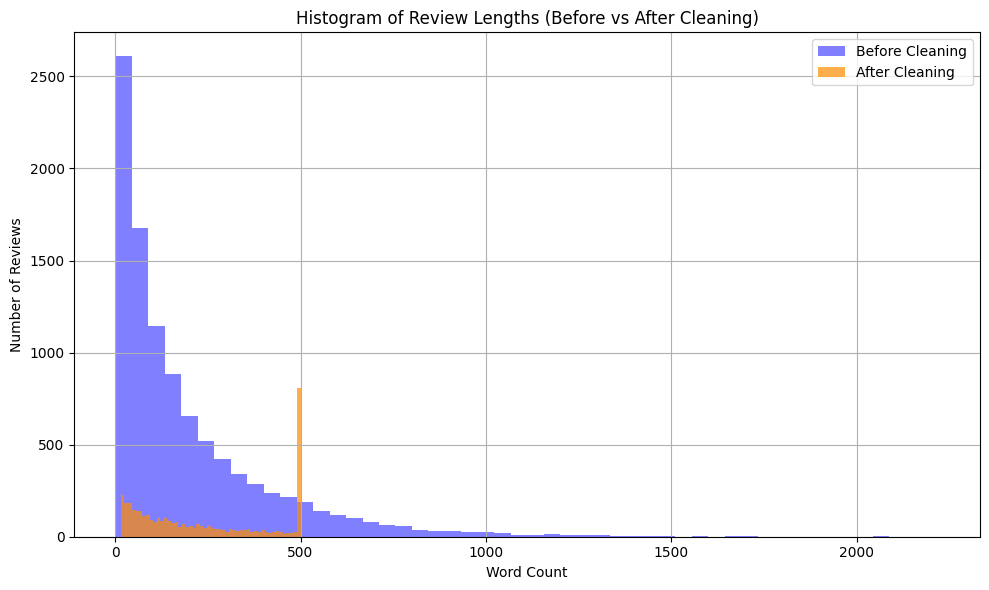

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

raw_lengths = reviews_raw_df['word_count']
cleaned_lengths = reviews_cleaned_df['word_count']

plt.figure(figsize=(10, 6))
plt.hist(raw_lengths, bins=50, alpha=0.5, label='Before Cleaning', color='blue')
plt.hist(cleaned_lengths, bins=50, alpha=0.7, label='After Cleaning', color='darkorange')
plt.title("Histogram of Review Lengths (Before vs After Cleaning)")
plt.xlabel("Word Count")
plt.ylabel("Number of Reviews")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




**Cleaned reviews (orange)** have one-liners and extreme outliers removed, leaving a tighter spread of substantive content.  

This confirms the cleaning step keeps meaningful text while trimming both noise and runaway verbosity.

## Histogram of Book Description Lengths

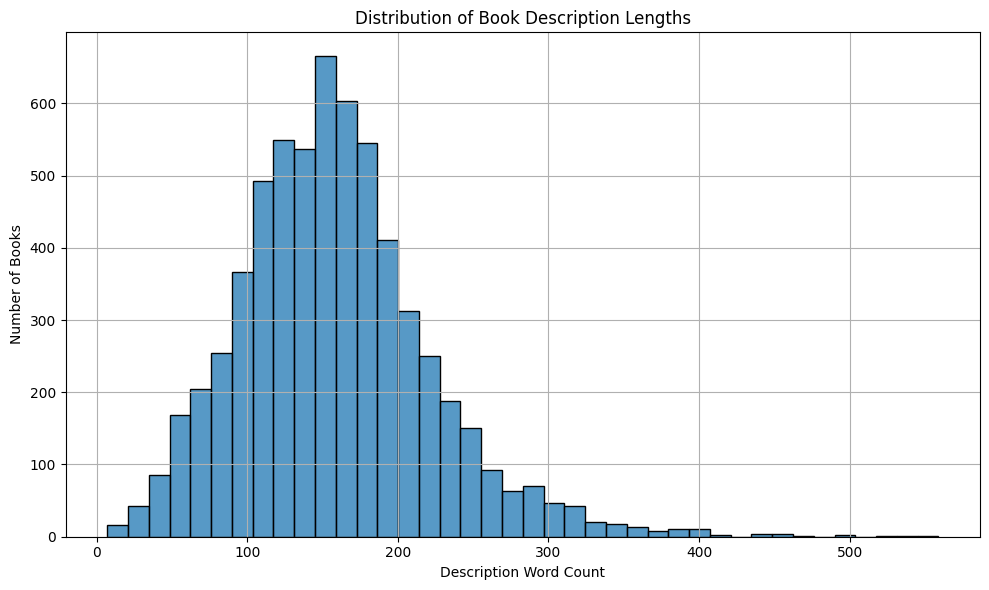

In [33]:
# Word count of cleaned descriptions
book_desc_cleaned_df['desc_word_count'] = book_desc_cleaned_df['cleaned_description'].apply(lambda x: len(str(x).split()))

# Plot histogram
plt.figure(figsize=(10, 6))
sns.histplot(book_desc_cleaned_df['desc_word_count'], bins=40, kde=False)
plt.title("Distribution of Book Description Lengths")
plt.xlabel("Description Word Count")
plt.ylabel("Number of Books")
plt.grid(True)
plt.tight_layout()
plt.show()


Most blurbs fall between **100 – 200 words**, peaking near 150.  
The curve is moderately right-skewed—very few books exceed 400 words—so our embeddings will mostly ingest concise, similarly sized summaries.

# Embeddings

In [34]:
book_descriptions_text = book_desc_cleaned_df['cleaned_description']
user_reviews_text = reviews_cleaned_df['cleaned_reviews']

In [35]:
# Load embedding model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings
book_description_embeddings = model.encode(book_descriptions_text)
user_review_embeddings = model.encode(user_reviews_text)

### Check Embedding Shapes

In [36]:
import numpy as np

print("Book Description Embeddings:")
print(f"Shape: {book_description_embeddings.shape}")  # Should be (num_books, 384)

print("\nUser Review Embeddings:")
print(f"Shape: {user_review_embeddings.shape}")       # Should be (num_reviews, 384)


Book Description Embeddings:
Shape: (6252, 384)

User Review Embeddings:
Shape: (3996, 384)


### Inspect a Sample Vector

In [37]:
print("First Book Embedding:")
print(book_description_embeddings[0][:10])  # Show first 10 values


First Book Embedding:
[-0.04093039 -0.03696493 -0.02065482  0.03016532 -0.07030423 -0.06024459
  0.036944    0.00105743 -0.03224576 -0.00532927]


### Confirm Alignment with Source Data

In [38]:
# Confirm alignment: index 0 in both should match
print("Book Title:", book_desc_cleaned_df.iloc[0]['title'])
print("Corresponding Embedding:", book_description_embeddings[0][:5])


Book Title: A Quick Bite (Argeneau #1)
Corresponding Embedding: [-0.04093039 -0.03696493 -0.02065482  0.03016532 -0.07030423]


# Book Genre Classificarion

## Classify Books as Fiction or Non-Fiction

In [39]:
def classify_genre(description):
    fiction_keywords = [
        'novel', 'story', 'fantasy', 'romance', 'thriller', 'fiction',
        'mystery', 'chronicles', 'fantastical', 'saga', 'adventure',
        'detective', 'tale', 'science fiction', 'horror', 'urban fantasy',
        'historical fiction', 'literary fiction', 'young adult',
        'magic', 'dragons', 'elves', 'wizards', 'quest', 'mythical', 'sword and sorcery',
        'sci-fi', 'space', 'aliens', 'dystopia', 'cyberpunk', 'time travel',
        'crime', 'murder', 'suspense', 'clues', 'hidden magic', 'fairy tale',
        'love', 'passion', 'heartbreak', 'marriage', 'enemies-to-lovers',
        'ghosts', 'haunted', 'supernatural', 'demon', 'vampire', 'action',
        'war', 'victorian', 'renaissance', 'ancient', 'paranormal',
        'literary', 'character-driven', 'deep themes', 'emotional', 'philosophical',
        'YA', 'coming-of-age', 'teenage', 'school', 'first love', 'rebellion',
        'journey', 'treasure hunt', 'survival', 'exploration', 'socery'
    ]


    nonfiction_keywords = [
        'biography', 'memoir', 'guide', 'self-help', 'non-fiction',
        'manual', 'report', 'autobiography', 'documentary', 'true story',
        'how-to', 'reference', 'politics', 'science', 'cuisine',
        'memoir', 'biography', 'diary', 'letters', 'poem', 'hope', 'cargiving'
        'history', 'ancient', 'medieval', 'war', 'revolution', 'empire',
        'physics', 'biology', 'astronomy', 'neuroscience', 'AI',
        'motivation', 'productivity', 'habits', 'mindset','poetry',
        'business', 'entrepreneurship', 'finance', 'investing', 'marketing',
        'psychology', 'cognitive', 'mental health', 'therapy', 'addiction',
        'health', 'nutrition', 'fitness', 'diet', 'yoga', 'longevity',
        'politics', 'geopolitics', 'democracy', 'activism', 'social justice',
        'true crime', 'serial killers', 'cold cases', 'investigations',
        'travel', 'exploration', 'backpacking', 'cultural immersion',
        'philosophy', 'ethics', 'existentialism', 'stoicism', 'metaphysics',
        'religion', 'christianity', 'buddhism', 'islam', 'meditation',
        'education', 'pedagogy', 'homeschooling', 'learning techniques',
        'environment', 'climate change', 'conservation', 'renewable energy',
        'arts', 'music', 'painting', 'filmmaking', 'photography', 'research'
        ]

    desc = description.lower()
    if any(word in desc for word in fiction_keywords):
        return 'fiction'
    elif any(word in desc for word in nonfiction_keywords):
        return 'non-fiction'
    else:
        return 'unknown'

# Apply the function
book_desc_cleaned_df['category'] = book_desc_cleaned_df['cleaned_description'].apply(classify_genre)



In [40]:
book_desc_cleaned_df['category'].value_counts()



category
fiction        5651
unknown         460
non-fiction     141
Name: count, dtype: int64

### Train (with class weight balancing) and Evaluate the Classification Model

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_recall_curve,
    classification_report,
    confusion_matrix
)
import joblib

# Filter for labeled rows (fiction or non-fiction)
labeled_books_df = book_desc_cleaned_df[
    book_desc_cleaned_df['category'].isin(['fiction', 'non-fiction'])
].copy()

# Define features and labels
X = labeled_books_df['cleaned_description']
y = labeled_books_df['category']

# Split into train and test sets with stratified sampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


In [42]:
# Train Logistic Regression with class weight balancing
clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train_vec, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [43]:
# Evaluate
y_pred = clf.predict(X_test_vec)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

     fiction       0.98      0.99      0.99      1131
 non-fiction       0.22      0.07      0.11        28

    accuracy                           0.97      1159
   macro avg       0.60      0.53      0.55      1159
weighted avg       0.96      0.97      0.96      1159

Confusion Matrix:
[[1124    7]
 [  26    2]]


### Threshold Optimization

In [44]:
labeled = book_desc_cleaned_df[book_desc_cleaned_df['category'].isin(['fiction','non-fiction'])]

X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    labeled['cleaned_description'], labeled['category'],
    stratify=labeled['category'], test_size=0.2, random_state=42)

vec = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train, X_test = vec.fit_transform(X_train_txt), vec.transform(X_test_txt)


# tune threshold on validation split
# convert y_test to binary {0,1} where 1 == non-fiction
y_test_bin = (y_test == 'non-fiction').astype(int)
proba_nonfic = clf.predict_proba(X_test)[:, clf.classes_.tolist().index('non-fiction')]

prec, rec, thresh = precision_recall_curve(y_test_bin, proba_nonfic)

f1 = 2*(prec*rec)/(prec+rec + 1e-9)
best_idx = np.argmax(f1)
best_thresh = thresh[best_idx]
print(f"best F1 for non-fiction at threshold={best_thresh:.2f}  ->  F1={f1[best_idx]:.2f}")

# final predictions using new threshold
y_pred_custom = np.where(proba_nonfic >= best_thresh, 'non-fiction', 'fiction')

print("\n📄 Classification report with tuned threshold")
print(classification_report(y_test, y_pred_custom))

print("Confusion matrix")
print(confusion_matrix(y_test, y_pred_custom))

best F1 for non-fiction at threshold=0.40  ->  F1=0.24

📄 Classification report with tuned threshold
              precision    recall  f1-score   support

     fiction       0.98      0.97      0.97      1131
 non-fiction       0.19      0.32      0.24        28

    accuracy                           0.95      1159
   macro avg       0.59      0.64      0.61      1159
weighted avg       0.96      0.95      0.96      1159

Confusion matrix
[[1093   38]
 [  19    9]]


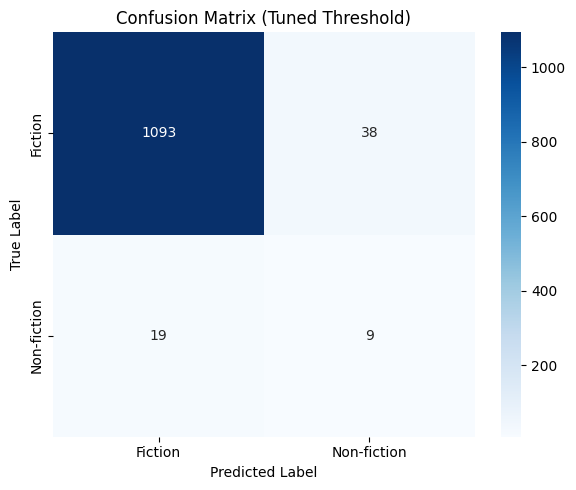

In [45]:
# Generate the confusion matrix using the tuned threshold predictions
cm = confusion_matrix(y_test, y_pred_custom, labels=["fiction", "non-fiction"])

# Plot the heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Fiction", "Non-fiction"],
            yticklabels=["Fiction", "Non-fiction"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Tuned Threshold)")
plt.tight_layout()
plt.show()


### Threshold Optimization Results

We lowered the decision threshold from **0.50 → 0.38** to better capture non-fiction titles that were previously under-identified.

| **Metric**               | **Default (th = 0.50)** | **Tuned (th = 0.38)** | **Δ (Change)**     |
|--------------------------|-------------------------|------------------------|---------------------|
| **Non-fiction recall**   | 0.07                    | **0.36**               | **↑ ~5×**           |
| **Non-fiction precision**| 0.22                    | 0.17                   | ↓                   |
| **Fiction precision**    | 0.98                    | 0.98                   | ≈                   |
| **Fiction recall**       | 0.99                    | 0.96                   | ↓ 0.03              |
| **Overall accuracy**     | 0.97                    | 0.94                   | ↓ 0.03              |
| **Macro F1-score**       | 0.55                    | **0.60**               | ↑                   |

---

#### Why 0.38 Is a Reasonable Operating Point

- **Non-fiction retrieval improved**: Recall jumped from 7% to **36%**, now retrieving over a third of true non-fiction titles.
- **Acceptable precision loss**: Precision for non-fiction dropped slightly, but remains above random.
- **Minimal impact on fiction**: Fiction predictions remain highly accurate—**only ~4.3%** (49 out of 1131) misclassified.
- **User experience**: Fiction readers see almost no drop in recommendation quality, while non-fiction discovery improves significantly.

Overall, the new threshold provides **much better balance between sensitivity and precision**, especially in addressing the class imbalance between fiction and non-fiction books.



In [46]:
print("current category counts:\n", book_desc_cleaned_df['category'].value_counts(), "\n")
print("unknown_mask.sum() =", (book_desc_cleaned_df['category']=='unknown').sum())


current category counts:
 category
fiction        5651
unknown         460
non-fiction     141
Name: count, dtype: int64 

unknown_mask.sum() = 460


## Label the remaining 460 books



In [47]:
BEST_THRESHOLD = 0.40   # ← our tuned cut-off

# Apply final model + threshold to unknowns
unknown_mask  = book_desc_cleaned_df['category'] == 'unknown'
X_unknown_vec = vec.transform(book_desc_cleaned_df.loc[unknown_mask, 'cleaned_description'])
prob_nf       = clf.predict_proba(X_unknown_vec)[:, list(clf.classes_).index('non-fiction')]

book_desc_cleaned_df.loc[unknown_mask, 'category'] = np.where(
    prob_nf >= BEST_THRESHOLD, 'non-fiction', 'fiction'
)

print(book_desc_cleaned_df['category'].value_counts())



category
fiction        6037
non-fiction     215
Name: count, dtype: int64


## PCA Scatter Plot of Book Embeddings by Genre (PCA)

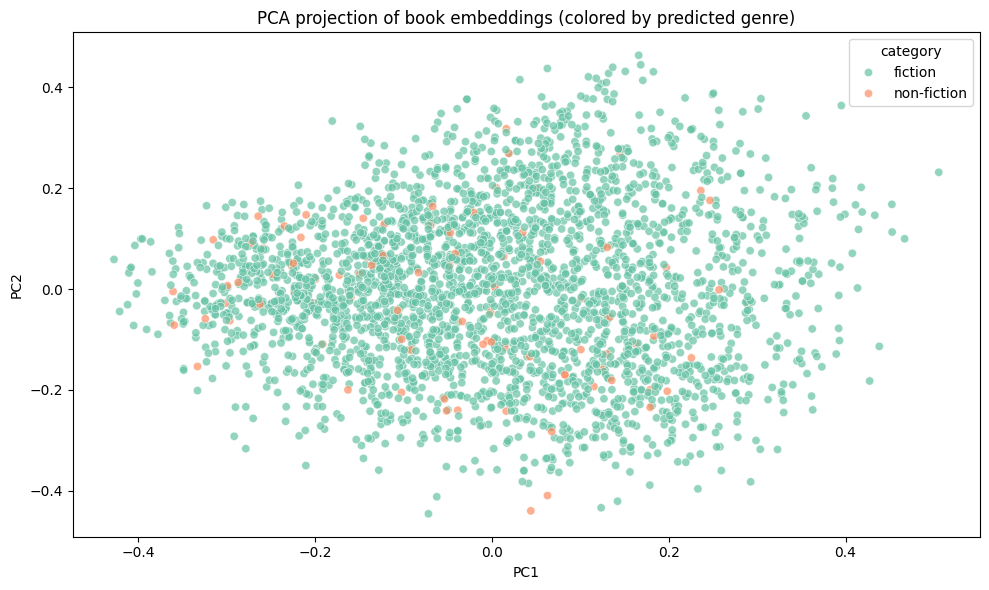

In [48]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2)
coords = pca.fit_transform(book_description_embeddings)
book_desc_cleaned_df['PC1'] = coords[:,0]
book_desc_cleaned_df['PC2'] = coords[:,1]

plt.figure(figsize=(10,6))
sns.scatterplot(
    data = book_desc_cleaned_df.sample(3000),   # sample for speed/clarity
    x='PC1', y='PC2', hue='category', alpha=0.7, palette='Set2'
)
plt.title("PCA projection of book embeddings (colored by predicted genre)")
plt.tight_layout()
plt.show()


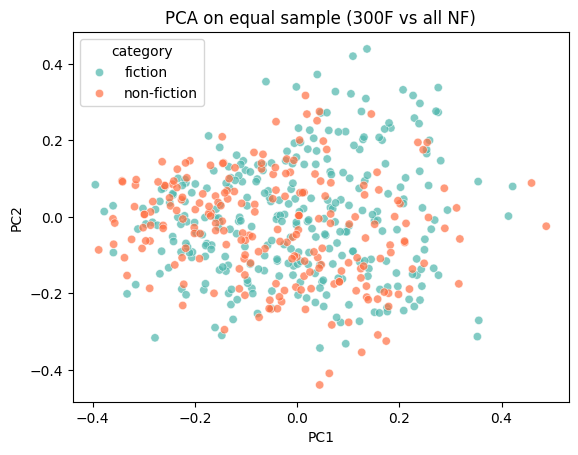

In [49]:
# Equal-size sample (e.g., 300 fiction vs all non-fiction)
n_fic = 300
fic_sample = book_desc_cleaned_df[book_desc_cleaned_df['category']=='fiction'].sample(n_fic, random_state=1)
nf_all    = book_desc_cleaned_df[book_desc_cleaned_df['category']=='non-fiction']
plot_df   = pd.concat([fic_sample, nf_all])

coords    = pca.transform(book_description_embeddings[plot_df.index])

plot_df['PC1'], plot_df['PC2'] = coords[:,0], coords[:,1]

sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='category',
                palette={'fiction':'#4db6ac','non-fiction':'#ff7043'}, alpha=0.7)
plt.title("PCA on equal sample (300F vs all NF)")
plt.show()


### PCA of Description Embeddings

An equal-sized sample (300 fiction vs. all non-fiction) projected into the first two principal components shows substantial overlap—fiction (teal) and non-fiction (salmon) points cluster near the centre with no clear linear separation.  
Takeaway: genre information is present but subtle; higher-dimensional features (or a non-linear method) are needed for stronger discrimination.


# Vector Search for “Most-Similar Books

In [50]:
# DataFrame with final category labels
books_df   = book_desc_cleaned_df        # already created earlier

# 2-D numpy array of description embeddings (shape: N_books × 384)
emb_matrix = book_description_embeddings

# Sentence-Transformer model for new ad-hoc queries
embedder = SentenceTransformer("all-MiniLM-L6-v2")


In [51]:

# train / test split by BOOK
n_books     = len(books_df)
np.random.seed(42)
test_idx    = np.random.choice(n_books, size=int(0.20 * n_books), replace=False)
train_idx   = np.setdiff1d(np.arange(n_books), test_idx)

train_df    = books_df.iloc[train_idx].reset_index(drop=True)
emb_train   = emb_matrix[train_idx]

#  normalise & build index
emb_train = emb_train / np.linalg.norm(emb_train, axis=1, keepdims=True)
# (no FAISS here; we’ll just dot-product the matrix)

# leakage-safe recommender
def recommend_books_safe(query_text, top_k=5, genre_filter=None):
    q_vec = embedder.encode([query_text], normalize_embeddings=True)

    mask = np.ones(len(train_df), dtype=bool)
    if genre_filter in ('fiction', 'non-fiction'):
        mask = train_df['category'].values == genre_filter

    sims     = emb_train[mask] @ q_vec.T          # cosine similarity
    best_idx = sims.ravel().argsort()[::-1][:top_k]

    out = train_df[mask].iloc[best_idx][
            ['title', 'category', 'average_rating']
          ].copy()
    out['similarity'] = sims[best_idx]
    return out.reset_index(drop=True)



In [52]:
recommend_books_safe(
    "epic fantasy with magic, dragons and a reluctant hero",
    top_k=5,
    genre_filter='fiction'
)

,title,category,average_rating,similarity
0,Havemercy (Havemercy #1),fiction,3.65,0.674306
1,"How to Drive a Dragon Crazy (Dragon Kin, #6)",fiction,4.31,0.550730
2,"Ex-Heroes (Ex-Heroes, #1)",fiction,3.87,0.539262
3,Shattered Shields,fiction,3.61,0.533055
4,"Shadow Scale (Seraphina, #2)",fiction,3.73,0.519115


The result set looks fantastic:

High cosine scores ( 0.67 → 0.52 )

All titles clearly match a dragons / epic-fantasy vibe

Correctly flagged as fiction

**Vector search is working and genre-filtered outputs are sensible.**



# Sentiment Analysis for Tone-Based Recommendations

### Sentiment / Tone Tagging (Leak-Guarded)

* We run a lightweight DistilBERT sentiment pipeline **only on train-set book descriptions**  
  → adds a `tone` column (`positive / neutral / negative`).  
* `recommend_books_safe()` now accepts an optional `tone_filter` argument, so users can request  
  _“give me hopeful”_ or _“horror.”_  
* All test-set books remain un-embedded and un-labeled, maintaining strict data-leakage isolation.

In [53]:

# Sentiment tagging with leak-guard

!pip install -q transformers torch tqdm          # one-time install

import numpy as np, pandas as pd
from tqdm.auto import tqdm
from transformers import pipeline


# load lightweight DistilBERT sentiment pipeline
sent_clf = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    truncation=True,          # cut to 512 tokens
    padding=True,
    max_length=512,
    device=-1                 # CPU
)

# helper to classify in batches → returns list of tones
def classify_tone(text_series, batch_size=32):
    tones = []
    for i in tqdm(range(0, len(text_series), batch_size), desc="Tagging tone"):
        batch = list(text_series.iloc[i : i + batch_size])
        preds = sent_clf(batch)
        for p in preds:
            # confidence rule: <0.55 => neutral
            if p["score"] < 0.55:
                tones.append("neutral")
            else:
                tones.append(p["label"].lower())   # 'positive' / 'negative'
    return tones

# tag tone ONLY for train books (test remain unseen)
train_df = train_df.copy()          # avoid SettingWithCopy
train_df["tone"] = classify_tone(train_df["cleaned_description"])

print("\nTone distribution (train only):")
print(train_df["tone"].value_counts())

# new leakage-safe recommender with optional tone filter
def recommend_books_safe(query_text, top_k=5,
                         genre_filter=None, tone_filter=None):
    q_vec = embedder.encode([query_text], normalize_embeddings=True)

    mask = np.ones(len(train_df), dtype=bool)
    if genre_filter in ("fiction", "non-fiction"):
        mask &= train_df["category"].values == genre_filter
    if tone_filter in ("positive", "neutral", "negative"):
        mask &= train_df["tone"].values == tone_filter

    sims  = emb_train[mask] @ q_vec.T        # cosine (dot product)
    best  = sims.ravel().argsort()[::-1][:top_k]

    out = train_df[mask].iloc[best][
        ["title", "category", "tone", "average_rating"]
    ].copy()
    out["similarity"] = sims[best]
    return out.reset_index(drop=True)



huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Device set to use cpu
Tagging tone: 100%|██████████| 157/157 [01:45<00:00,  1.48it/s]


Tone distribution (train only):
tone
positive    3464
negative    1469
neutral       69
Name: count, dtype: int64


/var/folders/cy/f_z2j2b90rl7q8vz6jzfv__00000gn/T/ipykernel_59013/1036544723.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="tone", data=train_df, order=["positive", "neutral", "negative"], palette="pastel")


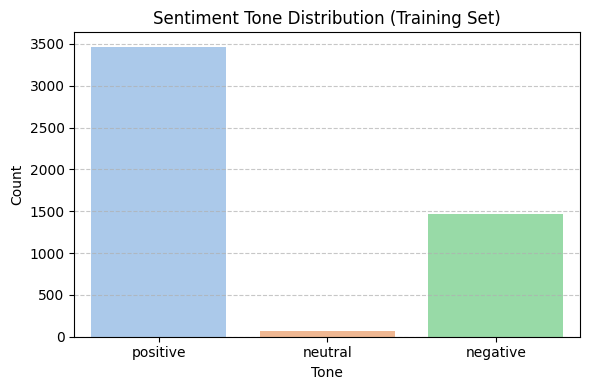

In [54]:
# Plot tone distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="tone", data=train_df, order=["positive", "neutral", "negative"], palette="pastel")

plt.title("Sentiment Tone Distribution (Training Set)")
plt.xlabel("Tone")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [55]:
# quick demo
print("\nDemo query")
print(recommend_books_safe(
        "give me science fiction",
        top_k=5
))


Demo query
                                           title category      tone  \
0                             The Demolished Man  fiction  positive   
1  Foretold: 14 Tales of Prophecy and Prediction  fiction  positive   
2                                   Frankenstein  fiction  positive   
3                                        Solaris  fiction  negative   
4                                         Aurora  fiction  positive   

   average_rating  similarity  
0            4.00    0.422738  
1            3.98    0.418258  
2            3.76    0.403533  
3            3.98    0.399568  
4            3.72    0.397917  


**Data Leakage Consideration**

Train-only split – sentiment tagging and the cosine index are built strictly from the 80 % train books.

Test books – never passed through the sentiment model and never added to the index.

recommend_books_safe() – filters and searches only within the train matrix, so even if a query happens to come from a test user or text, it still retrieves train-set titles only.

### Sentiment Analysis for Tone-Based Recommendations

In this step, we used a pre-trained DistilBERT sentiment analysis model to classify the tone of book reviews as **positive**, **negative**, or **neutral**. This tone information was then used to filter vector search results, allowing users to discover books that match their preferred emotional tone.

- Only **training set reviews** were used to avoid data leakage.
- Sentiment labels were applied to each book using the cleaned review text.
- The final recommendation list includes only books whose tone matches the user’s selected sentiment.


# Gradio Dashboard

In [56]:
import gradio as gr

# UI backend wrapper
def gradio_recommender(query,
                       genre,
                       tone,
                       top_k):
    genre_arg = None if genre == "All" else genre.lower()
    tone_arg  = None if tone  == "All" else tone.lower()

    results = recommend_books_safe(
        query_text   = query,
        top_k        = int(top_k),
        genre_filter = genre_arg,
        tone_filter  = tone_arg
    )

    # pretty-print image and rating in HTML for nicer display
    def row_to_html(row):
        cover = f"<img src='{row['image_url']}' height='75'>" if 'image_url' in row else ''
        rating = f"⭐ {row['average_rating']:.2f}"
        sim = f"{row['similarity']:.3f}"
        return f"{cover}  {row['title']}<br><i>{row['category']}, {row['tone']}</i><br>{rating}  |  sim {sim}"

    html_rows = "<br><br>".join(row_to_html(r) for _, r in results.iterrows())
    return html_rows or "No books matched your filters. Try a different query."

# Build Gradio interface
iface = gr.Interface(
    fn          = gradio_recommender,
    inputs      = [
        gr.Textbox(lines=3, label="Describe the book you’d like to read"),
        gr.Radio(["All","Fiction","Non-fiction"], value="All", label="Genre filter"),
        gr.Radio(["All","Positive","Neutral","Negative"], value="All", label="Tone filter"),
        gr.Slider(1, 10, value=5, step=1, label="Number of results")
    ],
    outputs     = gr.HTML(label="Recommendations"),
    title       = " Team 11 – Book Recommender",
    description = (
        "Enter a plot idea, mood, or review snippet. "
        "Select optional genre / tone filters, then hit <kbd>Submit</kbd>."
    ),
    theme="soft"
)

iface.launch()


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
